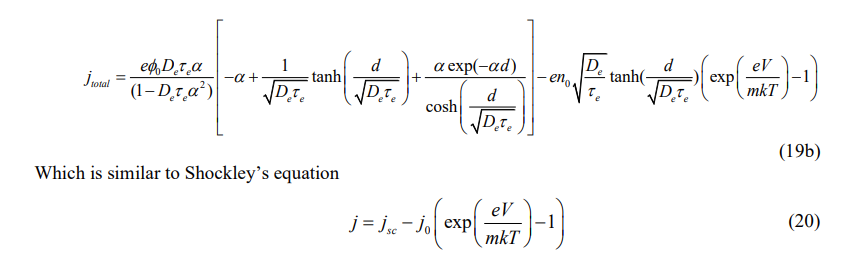


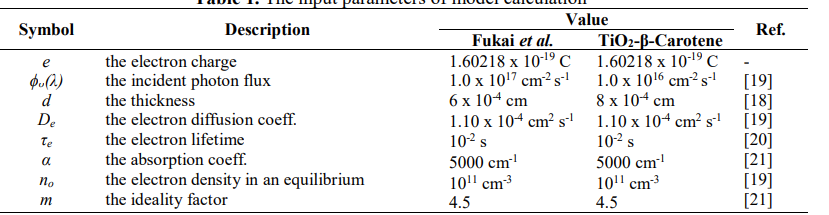



In [24]:
import numpy as np 
import pandas as pd
from scipy import constants , optimize
import matplotlib.pyplot as plt 
import scienceplots
plt.style.use(['science','no-latex','ieee'])
#import warnings

e, kB = constants.e, constants.Boltzmann
phi_0, d, T, alpha =1e16 ,8e-4 ,3e2, 5e3

def extended_shockley(V, m, n_0, tau_e, D_e):#, phi_0=phi0, d=d0, T=T0, alpha=alpha0):
    """ extended shockley equation is an shockley like's equation derive from maxwell equation?

    Args:
        V (float): voltage
        m (_float_): ideality factor constrains to 1 - 10
        n_0 (_float_): electron density in equilibrium
        tau_e (_float_): electron lifetime
        phi_0 (_float_, estimated): incident photon flux. Defaults to phi0.
        d (_float_, estimated): thickness. Defaults to d0.
        T (_float_, estimated): temperature. Defaults to T0.
        alpha (_type_, estimated): absorption coefficient. Defaults to alpha0.

    Returns:
        float: total current density
    """
    # Diffusion length L
    L = np.sqrt(D_e * tau_e)
    
    # Pre-factor for the first large bracket
    denom = 1 - (L**2 * alpha**2)
    term1_prefix = (e * phi_0 * L**2 * alpha) / denom
    
    # Contents of the square bracket []
    bracket = -alpha + (1/L * np.tanh(d/L)) + (alpha * np.exp(-alpha * d) / np.cosh(d/L))
    
    # short circuit current (density) , can be estimate from I with V ~ 0
    j_sc = term1_prefix * bracket
    
    # sqrt(D_e/tau_e) is the diffusion velocity
    j_0 = e * n_0 * np.sqrt(D_e / tau_e) * np.tanh(d/L)
    
    # Equation 20: j = j_sc - j_0 * (exp(eV/mkT) - 1)
    j_total = j_sc - j_0 * (np.exp((e * V) / (m * kB * T)) - 1)
    
    return j_total

file = "./data/shakinah.xlsx"
data = [pd.read_excel(file,sheet,header=2)  for sheet in pd.ExcelFile(file).sheet_names]
sheet_num = 1
jsc_from_data = data[sheet_num].iloc[data[sheet_num]["WE(1).Potential (V)"].abs().idxmin(), 2]
I,V =data[sheet_num]["mili A"], data[sheet_num]["WE(1).Potential (V)"]

initial_geuss = [ 4.5, 1e11, 1e-2, 1e-4] # from reference
low_lim, up_lim = [1, 0, 0, 0],[10, np.inf, np.inf, np.inf]

params, covs, info1, info2, info3 = optimize.curve_fit(extended_shockley,V,I,p0=initial_geuss, bounds=(low_lim, up_lim),full_output=True)

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


Fit converged!
m     = 8.594
n_0   = 1.210e+16 cm^-3
tau_e = 2.072e-03 s
D_e   = 4.059e-06 cm^2/s
Errors: m = 35316833.420, n_0 = 4.998e+09 cm^-3, tau_e = 3.618e+03 s, D_e = 8.328e+02 cm^2/s


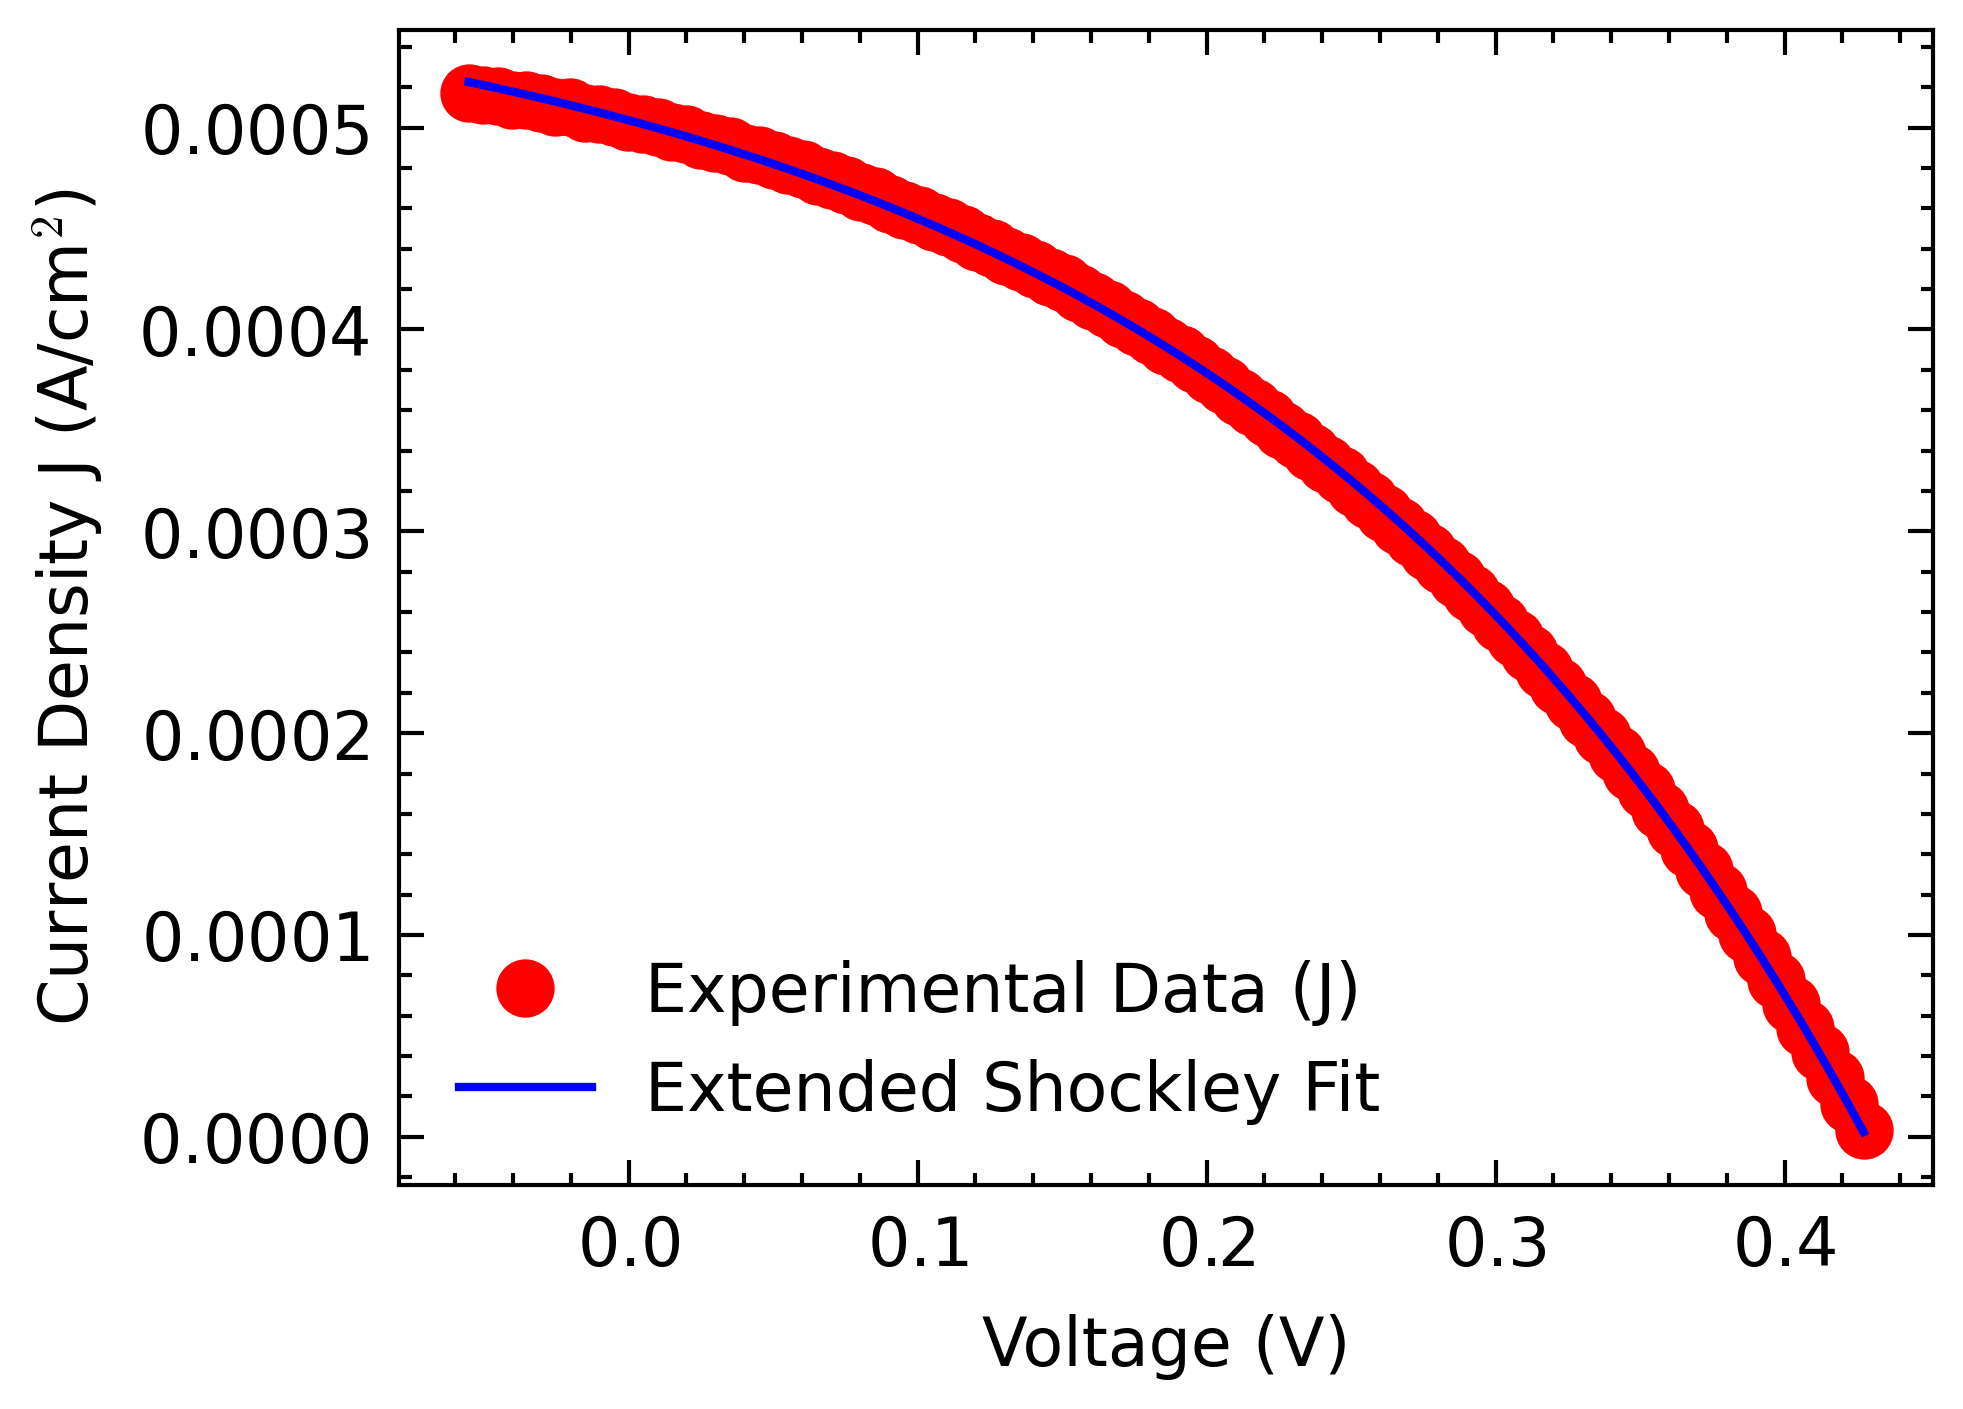

In [32]:
# Make sure your units are A/cm^2
AREA = 1.0 # Replace with the actual active area of your cell in cm^2
J_data = (I / 1000.0) / AREA # Convert mA to A/cm^2

# Wrap the function to explicitly scale parameters to O(1) magnitudes
# m ~ 1-10 
# n_0 ~ 1e14
# tau_e ~ 1e-2
# D_e ~ 1e-4 
def scaled_shockley(V, m, n0_scaled, tau_scaled, D_scaled):
    return extended_shockley(V, m, n0_scaled*1e14, tau_scaled*1e-2, D_scaled*1e-4)

# Initial guess corresponding to m=4.5, n0=1e14, tau=1e-2, D=1e-4
initial_guess_scaled = [2.35, 1.0, 1.0, 1.0]

# Tighter, physical bounds preventing values from blowing up
low_lim_scaled = [1.0, 1e-6, 1e-4, 1e-5]
up_lim_scaled = [20.0, 1e4, 1e4, 1e4] 

try:
    params_s, covs_s, info1, info2, info3 = optimize.curve_fit(
        scaled_shockley, V, J_data, 
        p0=initial_guess_scaled, 
        bounds=(low_lim_scaled, up_lim_scaled),
        full_output=True,
        method='trf',
        loss='cauchy'
    )
    print("Fit converged!")
    print(f"m     = {params_s[0]:.3f}")
    print(f"n_0   = {params_s[1]*1e14:.3e} cm^-3")
    print(f"tau_e = {params_s[2]*1e-2:.3e} s")
    print(f"D_e   = {params_s[3]*1e-4:.3e} cm^2/s")

    errors = np.sqrt(np.diag(covs))
    print(f"Errors: m = {errors[0]:.3f}, n_0 = {errors[1]*1e14:.3e} cm^-3, tau_e = {errors[2]*1e-2:.3e} s, D_e = {errors[3]*1e-4:.3e} cm^2/s")

    plt.figure()
    plt.plot(V, J_data, 'ro', label='Experimental Data (J)')
    plt.plot(V, scaled_shockley(V, *params_s), 'b-', label='Extended Shockley Fit')
    plt.xlabel("Voltage (V)")
    plt.ylabel("Current Density J (A/cm$^2$)")
    plt.legend()
    plt.show()
    
   
except Exception as e:
    print("Failed to converge. Error:", e)

In [35]:
errors = np.sqrt(np.diag(covs))
correlation_matrix = covs / np.outer(errors, errors)
print(correlation_matrix)

[[ 1.          0.99658766 -0.99057117  0.98730674]
 [ 0.99658766  1.         -0.99832725  0.99704731]
 [-0.99057117 -0.99832725  1.         -0.99942481]
 [ 0.98730674  0.99704731 -0.99942481  1.        ]]
